# 2D Navier-Stokes Experiment Setup: Mathematical Derivation & Numerical Scheme

## 1. The Primitive Equations (Velocity-Pressure Form)
We start with the incompressible Navier-Stokes equations for a Newtonian fluid on a 2D torus $\mathbb{T}^2 = [0, 2\pi]^2$. The primitive variables are velocity $\mathbf{u} = (u, v)^\top$ and pressure $p$.

$$
\begin{aligned}
\frac{\partial \mathbf{u}}{\partial t} + (\mathbf{u} \cdot \nabla) \mathbf{u} &= -\nabla p + \nu \Delta \mathbf{u} + \mathbf{f}, \\
\nabla \cdot \mathbf{u} &= 0,
\end{aligned}
$$

where $\nu$ is the kinematic viscosity and $\mathbf{f}$ is the external forcing.

## 2. The Vorticity-Streamfunction Formulation
To eliminate the pressure term $p$ and enforce incompressibility automatically, we take the curl ($\nabla \times$) of the momentum equation.

* **Vorticity ($\omega$):** defined as the scalar curl of velocity in 2D, $\omega = \frac{\partial v}{\partial x} - \frac{\partial u}{\partial y}$.
* **Streamfunction ($\psi$):** defined such that $\mathbf{u} = (\frac{\partial \psi}{\partial y}, -\frac{\partial \psi}{\partial x})^\top$.

The governing equation becomes a scalar transport equation:

$$
\frac{\partial \omega}{\partial t} = \underbrace{- (\mathbf{u} \cdot \nabla) \omega}_{\text{Nonlinear Advection } \mathcal{N}} + \underbrace{\nu \Delta \omega}_{\text{Linear Diffusion } \mathcal{L}} + f.
$$

The relationship between the variables is closed by the Poisson equation:

$$
\Delta \psi = -\omega.
$$

## 3. Spatial Discretization: Fourier Pseudo-Spectral Method
We apply the Discrete Fourier Transform (DFT) spatial discretization on an $N \times N$ grid. Let $\hat{\omega}_{\mathbf{k}}(t)$ denote the Fourier coefficient for wavenumber vector $\mathbf{k} = (k_x, k_y)^\top$.

### 3.1 Spectral Derivatives
In Fourier space, derivatives become algebraic multiplications:
* Gradient: $\nabla \rightarrow i\mathbf{k}$
* Laplacian: $\Delta \rightarrow -|\mathbf{k}|^2$

### 3.2 The Semi-Discrete Equation
The PDE transforms into a system of ODEs for each Fourier mode $\mathbf{k}$:

$$
\frac{d \hat{\omega}_{\mathbf{k}}}{dt} = \mathcal{L}_{\mathbf{k}} \hat{\omega}_{\mathbf{k}} + \mathcal{N}_{\mathbf{k}}(\hat{\omega}),
$$

where:
1.  **Linear Operator:** $\mathcal{L}_{\mathbf{k}} = -\nu |\mathbf{k}|^2$. This term is diagonal in spectral space and stiff (time-scale decays rapidly for high $\mathbf{k}$).
2.  **Nonlinear Operator:** $\mathcal{N}_{\mathbf{k}}(\hat{\omega}) = \text{FFT} \left[ - (\mathbf{u} \cdot \nabla) \omega + f \right]_{\mathbf{k}}$.

### 3.3 Computation of $\mathcal{N}_{\mathbf{k}}$ (Pseudo-spectral)
To avoid expensive convolutions, the nonlinear term is computed in physical space:
1.  **Invert Laplacian:** $\hat{\psi}_{\mathbf{k}} = -\hat{\omega}_{\mathbf{k}} / |\mathbf{k}|^2$ (set $\hat{\psi}_{\mathbf{0}} = 0$).
2.  **Get Velocities:** $\hat{u} = i k_y \hat{\psi}$, $\hat{v} = -i k_x \hat{\psi}$.
3.  **Get Gradients:** $\widehat{\omega_x} = i k_x \hat{\omega}$, $\widehat{\omega_y} = i k_y \hat{\omega}$.
4.  **IFFT:** Transform $\hat{u}, \hat{v}, \widehat{\omega_x}, \widehat{\omega_y}$ to physical space $u, v, \omega_x, \omega_y$.
5.  **Compute Advection:** Calculate scalar product $- (u \omega_x + v \omega_y)$ in physical space.
6.  **FFT:** Transform back to spectral space.
7.  **De-aliasing:** Apply the 2/3 rule (zero out top 1/3 frequencies) to remove aliasing errors.

## 4. Temporal Discretization: ETDRK4
We use the **Exponential Time Differencing Fourth-Order Runge-Kutta (ETDRK4)** scheme (Kassam & Trefethen, 2005). This method integrates the stiff linear part exactly using an integrating factor.

Multiplying by $e^{-\mathcal{L}t}$, the equation is integrated over a time step $h$:

$$
\hat{\omega}_{n+1} = e^{\mathcal{L}h} \hat{\omega}_n + \int_0^h e^{\mathcal{L}(h-\tau)} \mathcal{N}(\hat{\omega}(t_n + \tau)) d\tau.
$$

### 4.1 The Scheme Coefficients
Precompute the following operators (using contour integrals for numerical stability when $\mathcal{L} \approx 0$):
* $E = e^{\mathcal{L}h}, \quad E_2 = e^{\mathcal{L}h/2}$
* $Q = h (e^{\mathcal{L}h/2} - I)\mathcal{L}^{-1}$
* $f_1, f_2, f_3$: Higher order coefficients derived from polynomial approximation of the nonlinear term.

### 4.2 The Update Steps
1.  **Stage 1:** $N_1 = \mathcal{N}(\hat{\omega}_n)$
    $$a_k = E_2 \hat{\omega}_n + Q N_1$$
2.  **Stage 2:** $N_2 = \mathcal{N}(a_k)$
    $$b_k = E_2 \hat{\omega}_n + Q N_2$$
3.  **Stage 3:** $N_3 = \mathcal{N}(b_k)$
    $$c_k = E_2 a_k + Q(2N_3 - N_1)$$
4.  **Final Update:** $N_4 = \mathcal{N}(c_k)$
    $$\hat{\omega}_{n+1} = E \hat{\omega}_n + f_1 N_1 + 2 f_2 (N_2 + N_3) + f_3 N_4$$

## 5. Experimental Parameter Summary

| Parameter | Symbol | Value | Note |
| :--- | :--- | :--- | :--- |
| **Grid Size** | $N$ | $32$ | $32 \times 32$ grid ($d=1024$) |
| **Domain Length** | $L$ | $2\pi$ | Wavenumbers are integers $k \in \mathbb{Z}$ |
| **Viscosity** | $\nu$ | $10^{-3}$ | Determines Reynolds number |
| **Forcing** | $f(x,y)$ | $-4 \cos(4y)$ | Kolmogorov forcing |
| **Time Step** | $\delta t$ | $0.01$ | Internal solver step size |
| **Initial Condition** | $\omega_0$ | $\text{GRF}(\alpha=3)$ | Smooth Gaussian Random Field |

In [1]:
cd ..

/home/bhchen/LearnKalmanGain


Generating NS data using gen_data...
Train traj shape: torch.Size([1002, 1, 1024])
Inferred grid size: N=32, batch=1
Sanity check - max: 32.586662
Sanity check - min: -36.08933
Saved GIF to: ns_etdrk4_gen_data.gif
Displaying 3 keyframes...


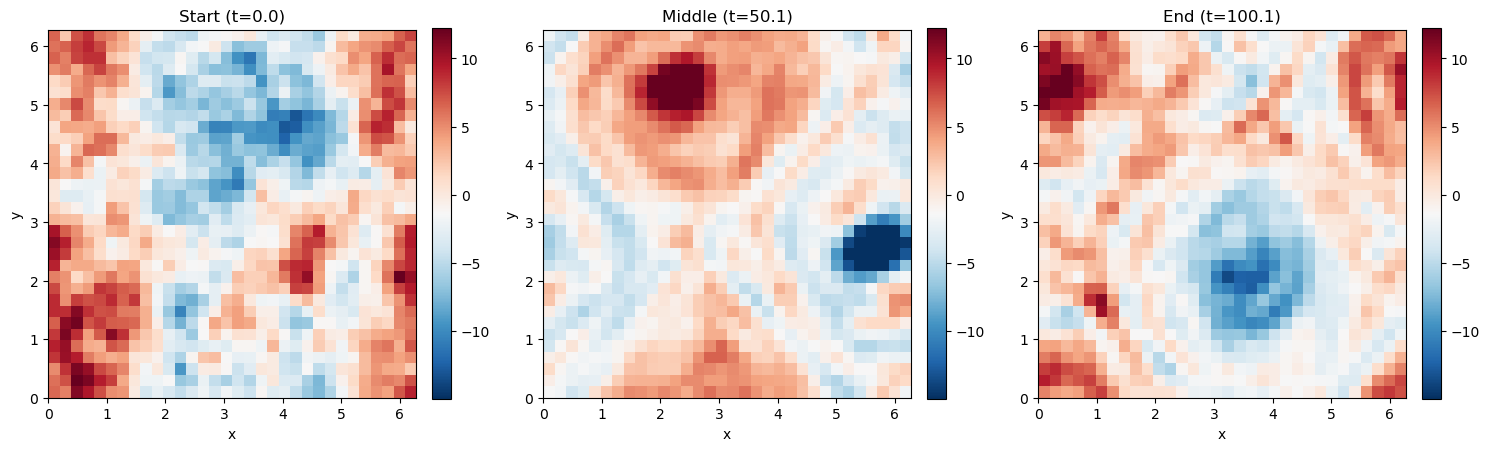

In [3]:
# test_ns_gen_data.py
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import animation

from utils import gen_data


def main():
    """
    Functionality: 
      1. Generates Navier-Stokes data via gen_data.
      2. Reshapes trajectory to grid format.
      3. Saves an animated GIF.
      4. Displays 3 static keyframes (Start, Middle, End).
    Input: None
    Output: None (Saves GIF to disk and displays plot)
    """

    dataset = "ns"

    # Time grid
    T = 1000
    dt = 0.1
    t = torch.linspace(0, T * dt, T + 1)

    # gen_data params
    steps_test = 10
    steps_valid = 5

    class Args:
        ori_dim = None

    args = Args()

    print("Generating NS data using gen_data...")

    v_traj, v_valid, v_test = gen_data(
        dataset=dataset,
        t=t,
        steps_test=steps_test,
        steps_valid=steps_valid,
        args=args,
        v0=None,
        sigma_v=0,
        check_disk=False,
        steps_burn=1000,
        dt_iter=10,
        prefix="debug_",
        test_only=False,
    )

    print("Train traj shape:", v_traj.shape)
    
    # (T+1, B, N*N) -> dim check
    dim = v_traj.shape[2]
    N = int(np.sqrt(dim))
    print(f"Inferred grid size: N={N}, batch={v_traj.shape[1]}")

    # Convert to numpy: (T+1, N, N) for the first batch member
    data = v_traj[:, 0].view(-1, N, N).cpu().numpy()

    # Stats
    print("Sanity check - max:", np.nanmax(data))
    print("Sanity check - min:", np.nanmin(data))

    # -----------------------------
    # 1. GIF configuration
    # -----------------------------
    gif_path = "ns_etdrk4_gen_data.gif"
    frame_stride = 20
    frames = data[::frame_stride]
    times = (np.arange(frames.shape[0]) * frame_stride) * dt

    # Fixed color range
    vmin = np.nanpercentile(frames, 1)
    vmax = np.nanpercentile(frames, 99)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmin, vmax = -1.0, 1.0

    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(
        frames[0],
        origin="lower",
        extent=[0, 2 * np.pi, 0, 2 * np.pi],
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        animated=True,
    )
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    title = ax.set_title(f"t={times[0]:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    def update(i):
        im.set_array(frames[i])
        title.set_text(f"t={times[i]:.2f}")
        return (im, title)

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(frames),
        interval=50,
        blit=False,
    )

    writer = animation.PillowWriter(fps=10)
    ani.save(gif_path, writer=writer, dpi=120)
    plt.close(fig)
    print(f"Saved GIF to: {gif_path}")

    # -----------------------------
    # 2. Keyframes Visualization
    # -----------------------------
    # Select indices: Start, Middle, End
    key_indices = [0, len(data) // 2, len(data) - 1]
    key_labels = ["Start", "Middle", "End"]

    fig_k, axes_k = plt.subplots(1, 3, figsize=(15, 5))
    
    for ax, idx, label in zip(axes_k, key_indices, key_labels):
        current_t = idx * dt
        im_k = ax.imshow(
            data[idx],
            origin="lower",
            extent=[0, 2 * np.pi, 0, 2 * np.pi],
            cmap="RdBu_r",
            vmin=vmin,
            vmax=vmax
        )
        ax.set_title(f"{label} (t={current_t:.1f})")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        plt.colorbar(im_k, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    print("Displaying 3 keyframes...")
    plt.show()


if __name__ == "__main__":
    main()